In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collections and Processing

In [6]:
gold_data = pd.read_csv("C:/Users/nivedhini27/Downloads/gld_price_data.csv")

In [7]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [8]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:
gold_data.shape

(2290, 6)

In [10]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [13]:
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [14]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation

In [24]:
correlation = gold_data.corr(numeric_only=True)

<Axes: >

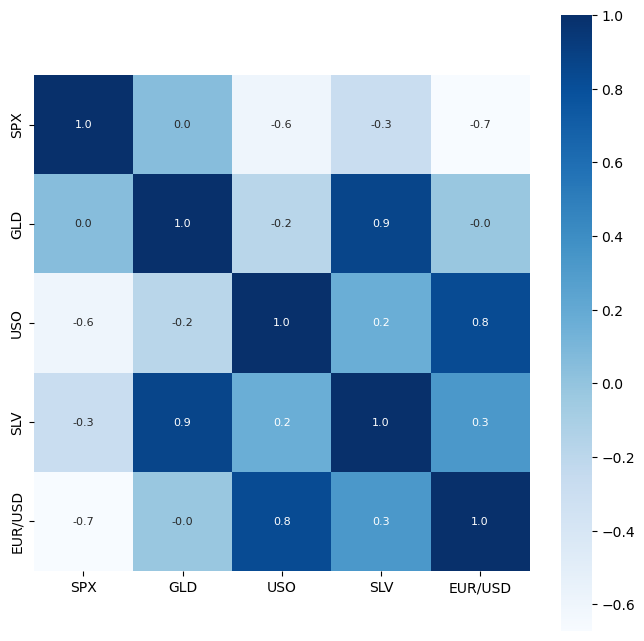

In [26]:
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [27]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


C:\Users\nivedhini27\AppData\Local\Temp\ipykernel_6892\4227780549.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

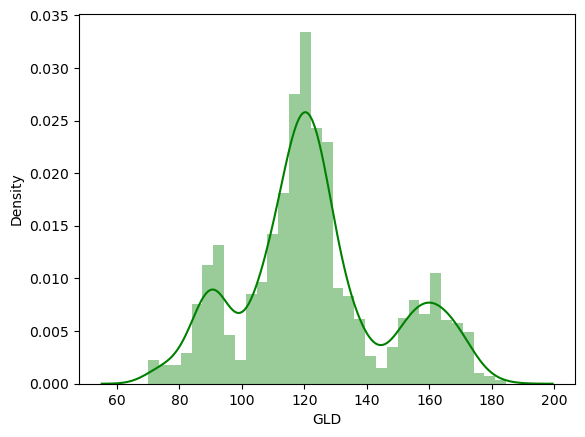

In [31]:
sns.distplot(gold_data['GLD'],color='green')

Splitting the Features and Target

In [38]:
X = gold_data.drop(['Date', 'GLD'], axis=1)
Y = gold_data['GLD']
print(X)
print(Y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training and Test Data

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

Model Training : Random Forest Algorithm

In [46]:
regressor = RandomForestRegressor(n_estimators=100)

In [47]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

Model Evaluation

In [48]:
test_data_prediction = regressor.predict(X_test)
print(test_data_prediction)

[168.77539979  81.72969989 115.76669978 127.75530091 120.88780136
 154.49639753 150.49279916 125.9820003  117.57149903 125.96310075
 116.73480108 172.07050096 141.16229832 167.67229883 115.30150034
 117.7841007  138.72920348 170.10740162 159.68890314 159.50359944
 155.20540046 125.29379999 175.28840022 156.53410313 125.14760017
  93.75559983  77.14160028 120.22500016 119.06989951 167.4212999
  88.4430003  125.42720048  91.2234006  117.61510026 121.14369934
 136.34870042 115.47040127 115.31240057 146.82470079 107.52950095
 104.32540255  87.32159831 126.58050083 118.11929963 153.24739898
 119.58250016 108.50809968 108.26399821  93.2757006  127.06709791
  74.9648003  113.7609992  121.24290019 111.28069931 118.79139927
 120.45829958 159.09260018 168.03300096 147.04019679  86.02509881
  94.42350023  86.82879907  90.52020013 118.94320069 126.44960058
 127.49630003 168.91499938 122.18689941 117.32359869  98.56430043
 168.07940084 143.02479848 132.3382018  121.10250215 120.67019952
 119.725300

In [51]:
error_score = metrics.r2_score(Y_test, test_data_prediction)
print('R^2 error : ',error_score)

R^2 error :  0.9890508509477677


Compare Actual Values and Predicted Values in a Plot

In [52]:
Y_test = list(Y_test)

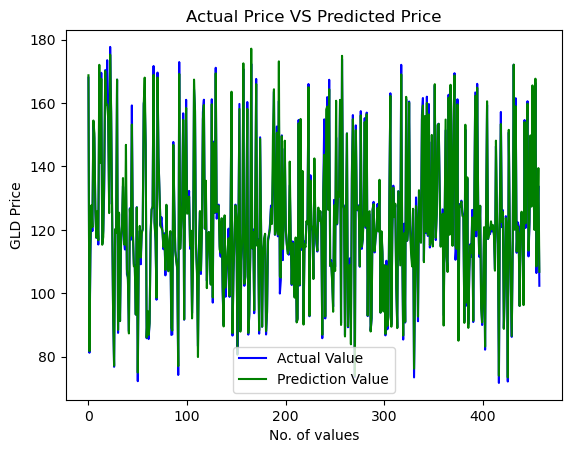

In [55]:
plt.plot(Y_test, color='blue',label = 'Actual Value')
plt.plot(test_data_prediction, color='green',label = 'Prediction Value')
plt.title("Actual Price VS Predicted Price")
plt.xlabel('No. of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()